# Predicting UFC Fight Finish Probability Using Machine Learning

## 1. Problem Statement and Business Value
This project predicts whether a UFC fight is more likely to end in a finish or go to a judges' decision. This can support sports media previews, fan engagement, fight analysis, and content planning.

In [1]:
!pip install kagglehub -q

import kagglehub
import os
import pandas as pd
import numpy as np

# Download full Kaggle dataset
dataset_path = kagglehub.dataset_download("rajeevw/ufcdata")

print("Dataset folder:", dataset_path)
print("Files available:")
print(os.listdir(dataset_path))

# Load main modeling dataset
df = pd.read_csv(os.path.join(dataset_path, "data.csv"))

# Load raw fight outcome dataset
raw_df = pd.read_csv(
    os.path.join(dataset_path, "raw_total_fight_data.csv"),
    sep=";"
)

print("Main dataset shape:", df.shape)
print("Raw dataset shape:", raw_df.shape)

df.head()

Using Colab cache for faster access to the 'ufcdata' dataset.
Dataset folder: /kaggle/input/ufcdata
Files available:
['raw_total_fight_data.csv', 'data.csv', 'preprocessed_data.csv', 'raw_fighter_details.csv']
Main dataset shape: (6012, 144)
Raw dataset shape: (6012, 41)


,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,...,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,...,0,3,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0
2,Tai Tuivasa,Harry Hunsucker,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Heavyweight,NaN,NaN,...,1,3,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0
3,Cheyanne Buys,Montserrat Conejo,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenStrawweight,NaN,NaN,...,0,0,0,0,Switch,160.02,160.02,115.0,28.0,25.0
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125,0.0,...,1,2,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 2. Dataset Overview
The project uses historical UFC fight data from Kaggle. The main dataset provides pre-fight fighter statistics, while the raw fight dataset provides the actual fight result method used to create the target variable.

In [2]:
df.columns.tolist()

['R_fighter',
 'B_fighter',
 'Referee',
 'date',
 'location',
 'Winner',
 'title_bout',
 'weight_class',
 'B_avg_KD',
 'B_avg_opp_KD',
 'B_avg_SIG_STR_pct',
 'B_avg_opp_SIG_STR_pct',
 'B_avg_TD_pct',
 'B_avg_opp_TD_pct',
 'B_avg_SUB_ATT',
 'B_avg_opp_SUB_ATT',
 'B_avg_REV',
 'B_avg_opp_REV',
 'B_avg_SIG_STR_att',
 'B_avg_SIG_STR_landed',
 'B_avg_opp_SIG_STR_att',
 'B_avg_opp_SIG_STR_landed',
 'B_avg_TOTAL_STR_att',
 'B_avg_TOTAL_STR_landed',
 'B_avg_opp_TOTAL_STR_att',
 'B_avg_opp_TOTAL_STR_landed',
 'B_avg_TD_att',
 'B_avg_TD_landed',
 'B_avg_opp_TD_att',
 'B_avg_opp_TD_landed',
 'B_avg_HEAD_att',
 'B_avg_HEAD_landed',
 'B_avg_opp_HEAD_att',
 'B_avg_opp_HEAD_landed',
 'B_avg_BODY_att',
 'B_avg_BODY_landed',
 'B_avg_opp_BODY_att',
 'B_avg_opp_BODY_landed',
 'B_avg_LEG_att',
 'B_avg_LEG_landed',
 'B_avg_opp_LEG_att',
 'B_avg_opp_LEG_landed',
 'B_avg_DISTANCE_att',
 'B_avg_DISTANCE_landed',
 'B_avg_opp_DISTANCE_att',
 'B_avg_opp_DISTANCE_landed',
 'B_avg_CLINCH_att',
 'B_avg_CLINCH_lande

## 3. Target Variable
The target variable is `finish_vs_decision`. Fights ending by KO/TKO, submission, or doctor stoppage are labeled as Finish. Fights ending by unanimous, split, or majority decision are labeled as Decision.

In [3]:
# Remove old columns if this cell has been run before
df = df.drop(columns=["win_by", "true_win_by", "finish_vs_decision", "date_clean"], errors="ignore")

# Convert dates in both datasets to the same format for merging
df["date_clean"] = pd.to_datetime(df["date"], errors="coerce").dt.date
raw_df["date_clean"] = pd.to_datetime(raw_df["date"], errors="coerce").dt.date

# Pull only the true fight outcome from the raw dataset
raw_target = raw_df[
    ["R_fighter", "B_fighter", "date_clean", "win_by"]
].drop_duplicates(
    subset=["R_fighter", "B_fighter", "date_clean"]
).rename(columns={
    "win_by": "true_win_by"
})

# Merge the true current-fight win method into data.csv
df = df.merge(
    raw_target,
    on=["R_fighter", "B_fighter", "date_clean"],
    how="left"
)

print("Missing true win_by values after merge:", df["true_win_by"].isna().sum())
print()
print("True win_by value counts:")
print(df["true_win_by"].value_counts(dropna=False).head(15))
# Create binary target variable: Finish vs Decision

def classify_finish_vs_decision(method):
    method = str(method).lower()

    if "decision" in method:
        return "Decision"
    elif (
        "ko" in method
        or "tko" in method
        or "submission" in method
        or "doctor" in method
    ):
        return "Finish"
    else:
        return "Other"

df["finish_vs_decision"] = df["true_win_by"].apply(classify_finish_vs_decision)

# Keep only Finish and Decision fights
df = df[df["finish_vs_decision"].isin(["Finish", "Decision"])].copy()
# Feature engineering: age difference between red and blue fighter
df["age_difference"] = df["R_age"] - df["B_age"]

print("Target distribution:")
print(df["finish_vs_decision"].value_counts())

print()
print("Original win method mapped to target:")
print(df[["true_win_by", "finish_vs_decision"]].value_counts().head(20))

Missing true win_by values after merge: 0

True win_by value counts:
true_win_by
Decision - Unanimous       2097
KO/TKO                     1905
Submission                 1210
Decision - Split            568
TKO - Doctor's Stoppage      80
Decision - Majority          66
Overturned                   49
DQ                           18
Could Not Continue           17
Other                         2
Name: count, dtype: int64
Target distribution:
finish_vs_decision
Finish      3195
Decision    2731
Name: count, dtype: int64

Original win method mapped to target:
true_win_by              finish_vs_decision
Decision - Unanimous     Decision              2097
KO/TKO                   Finish                1905
Submission               Finish                1210
Decision - Split         Decision               568
TKO - Doctor's Stoppage  Finish                  80
Decision - Majority      Decision                66
Name: count, dtype: int64


### Removing Special-Case Weight Classes

OpenWeight and CatchWeight were removed because they are unusual or special-case divisions that may not represent normal UFC matchmaking. Removing them makes the model more focused on standard UFC weight classes.

In [4]:
# Optional: remove unusual historical or special-case weight classes
df = df[~df["weight_class"].isin(["OpenWeight", "CatchWeight"])].copy()

## 4. Data Leakage Prevention
Outcome-related columns such as Winner, true_win_by, fighter names, date, location, and referee were removed from the model features. This helps prevent the model from learning information that would not be available before the fight.

In [5]:
leakage_cols = [
    "Winner",
    "true_win_by",
    "win_by",
    "last_round",
    "last_round_time",
    "Format",
    "Referee",
    "date",
    "date_clean",
    "location",
    "R_fighter",
    "B_fighter"
]

leakage_cols = [col for col in leakage_cols if col in df.columns]

df_model = df.drop(columns=leakage_cols)

print("Removed leakage columns:")
print(leakage_cols)

print()
print("Model dataset shape:", df_model.shape)
df_model.head()

Removed leakage columns:
['Winner', 'true_win_by', 'Referee', 'date', 'date_clean', 'location', 'R_fighter', 'B_fighter']

Model dataset shape: (5789, 140)


,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,...,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age,finish_vs_decision,age_difference
0,False,Bantamweight,0.000,0.0,0.420000,0.49500,0.330,0.36000,0.500,1.0000,...,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0,Finish,-4.0
1,False,Middleweight,0.500,0.0,0.660000,0.30500,0.300,0.50000,1.500,0.0000,...,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0,Decision,-4.0
2,False,Heavyweight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0,Finish,-4.0
3,False,WomenStrawweight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Switch,160.02,160.02,115.0,28.0,25.0,Decision,-3.0
4,False,WomenBantamweight,0.125,0.0,0.535625,0.57875,0.185,0.16625,0.125,0.1875,...,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0,Decision,14.0


## 5. Exploratory Data Analysis
The EDA section reviews the class balance between Finish and Decision outcomes and compares finish rates across UFC weight classes.

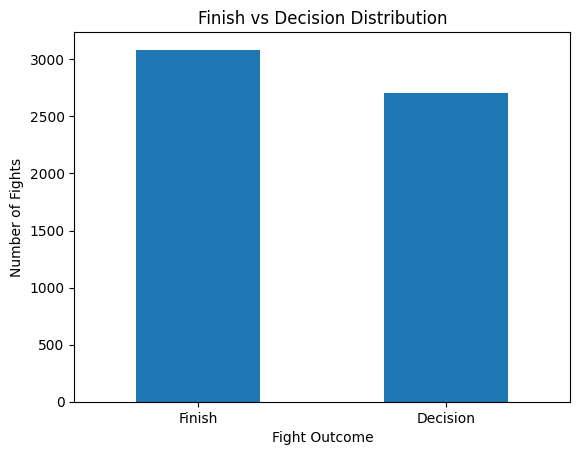

,count
finish_vs_decision,
Finish,3084
Decision,2705


In [6]:
import matplotlib.pyplot as plt

target_counts = df["finish_vs_decision"].value_counts()

target_counts.plot(kind="bar")
plt.title("Finish vs Decision Distribution")
plt.xlabel("Fight Outcome")
plt.ylabel("Number of Fights")
plt.xticks(rotation=0)
plt.show()

target_counts

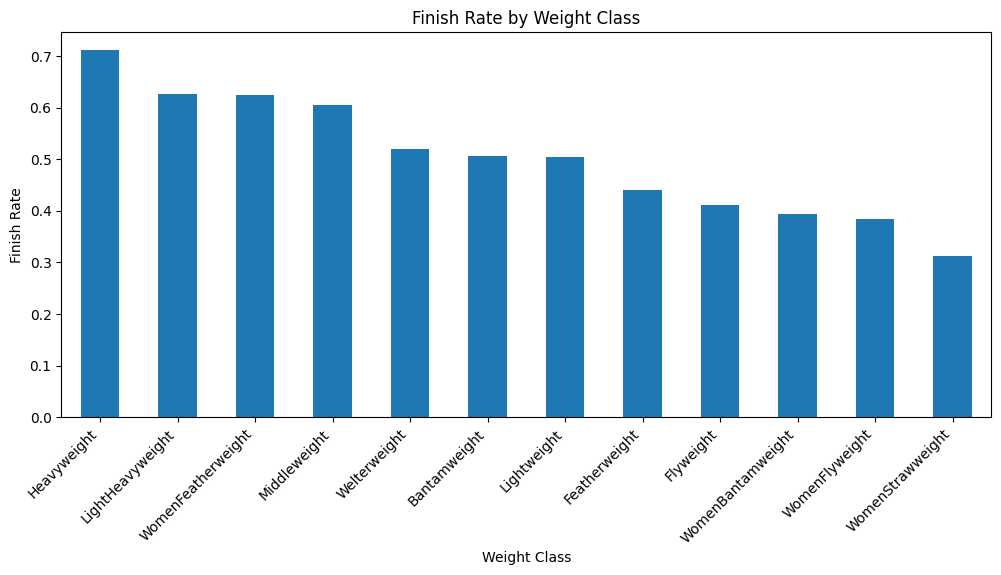

,finish_vs_decision
weight_class,
Heavyweight,0.710801
LightHeavyweight,0.626118
WomenFeatherweight,0.625000
Middleweight,0.605985
Welterweight,0.520599
Bantamweight,0.505376
Lightweight,0.504171
Featherweight,0.440147
Flyweight,0.410480


In [7]:
finish_rate_by_weight = (
    df.groupby("weight_class")["finish_vs_decision"]
    .apply(lambda x: (x == "Finish").mean())
    .sort_values(ascending=False)
)

finish_rate_by_weight.plot(kind="bar", figsize=(12, 5))
plt.title("Finish Rate by Weight Class")
plt.xlabel("Weight Class")
plt.ylabel("Finish Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

finish_rate_by_weight

In [8]:
# EDA: Review age difference by fight outcome
df.groupby("finish_vs_decision")["age_difference"].describe()

,count,mean,std,min,25%,50%,75%,max
finish_vs_decision,,,,,,,,
Decision,2680.0,0.450373,4.997028,-15.0,-3.0,0.0,4.0,17.0
Finish,2997.0,0.188188,5.423883,-17.0,-3.0,0.0,4.0,16.0


## Feature and Target Setup

The dataset is split into features, represented by X, and the target variable, represented by y. The model uses pre-fight fighter statistics to predict whether the fight ended in a Finish or Decision.

In [9]:
X = df_model.drop(columns=["finish_vs_decision"])
y = df_model["finish_vs_decision"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Feature shape: (5789, 139)
Target shape: (5789,)
finish_vs_decision
Finish      3084
Decision    2705
Name: count, dtype: int64


In [10]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("Categorical columns:")
print(categorical_features)


Numeric features: 135
Categorical features: 4
Categorical columns:
['title_bout', 'weight_class', 'B_Stance', 'R_Stance']


## Preprocessing and Train/Test Split

The data is split into training and testing sets. Numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded. This keeps preprocessing inside the machine learning pipeline.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target label mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Data split and preprocessor defined.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Target label mapping:
{'Decision': np.int64(0), 'Finish': np.int64(1)}
Data split and preprocessor defined.
X_train shape: (4631, 139)
y_train shape: (4631,)


## 6. Model Comparison

Four classification models were compared: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. After removing unusual historical weight classes such as OpenWeight and CatchWeight, Gradient Boosting performed best overall based on weighted F1-score. The final results were realistic but modest, showing that UFC fight outcomes are difficult to predict using historical pre-fight data alone.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Finish": precision_score(y_test, y_pred, pos_label=1),
        "Recall_Finish": recall_score(y_test, y_pred, pos_label=1),
        "F1_Finish": f1_score(y_test, y_pred, pos_label=1),
        "F1_Macro": f1_score(y_test, y_pred, average="macro"),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1_Weighted", ascending=False)
results_df

,Model,Accuracy,Precision_Finish,Recall_Finish,F1_Finish,F1_Macro,F1_Weighted,ROC-AUC
3,Gradient Boosting,0.569948,0.589744,0.633712,0.610938,0.565121,0.568128,0.590690
2,Random Forest,0.566494,0.591415,0.602917,0.597111,0.563976,0.566151,0.590452
1,Decision Tree,0.548359,0.577815,0.565640,0.571663,0.547019,0.548636,0.547145
0,Logistic Regression,0.545769,0.568216,0.614263,0.590343,0.540326,0.543609,0.596033


## 7. Final Model Results

The best model was Gradient Boosting based on weighted F1-score. It achieved approximately 57% accuracy, 0.57 weighted F1-score, and 0.59 ROC-AUC. Logistic Regression had a slightly higher ROC-AUC, but Gradient Boosting was selected because it had the best overall weighted F1-score.

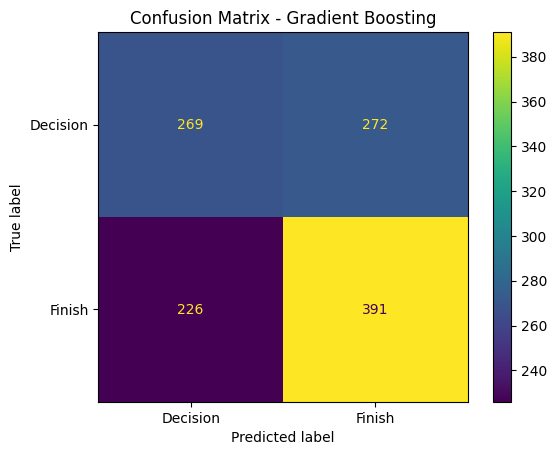

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [14]:
from sklearn.metrics import classification_report

print("Best Model:", best_model_name)
print()
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))

Best Model: Gradient Boosting

              precision    recall  f1-score   support

    Decision       0.54      0.50      0.52       541
      Finish       0.59      0.63      0.61       617

    accuracy                           0.57      1158
   macro avg       0.57      0.57      0.57      1158
weighted avg       0.57      0.57      0.57      1158



### Feature Importance

Feature importance was reviewed to better understand which variables had the strongest influence on the final model’s predictions.

                               Feature  Importance
130                   num__R_Reach_cms    0.056180
65                   num__B_Weight_lbs    0.046915
131                  num__R_Weight_lbs    0.035086
48   num__B_total_time_fought(seconds)    0.032071
34             num__B_avg_DISTANCE_att    0.022193
101         num__R_avg_DISTANCE_landed    0.021893
68              num__R_avg_SIG_STR_pct    0.020807
64                    num__B_Reach_cms    0.020416
89              num__R_avg_HEAD_landed    0.019796
81         num__R_avg_TOTAL_STR_landed    0.018492
98              num__R_avg_opp_LEG_att    0.018163
18                   num__B_avg_TD_att    0.016544
108              num__R_avg_GROUND_att    0.016070
134                num__age_difference    0.015525
7               num__B_avg_opp_SUB_ATT    0.015111


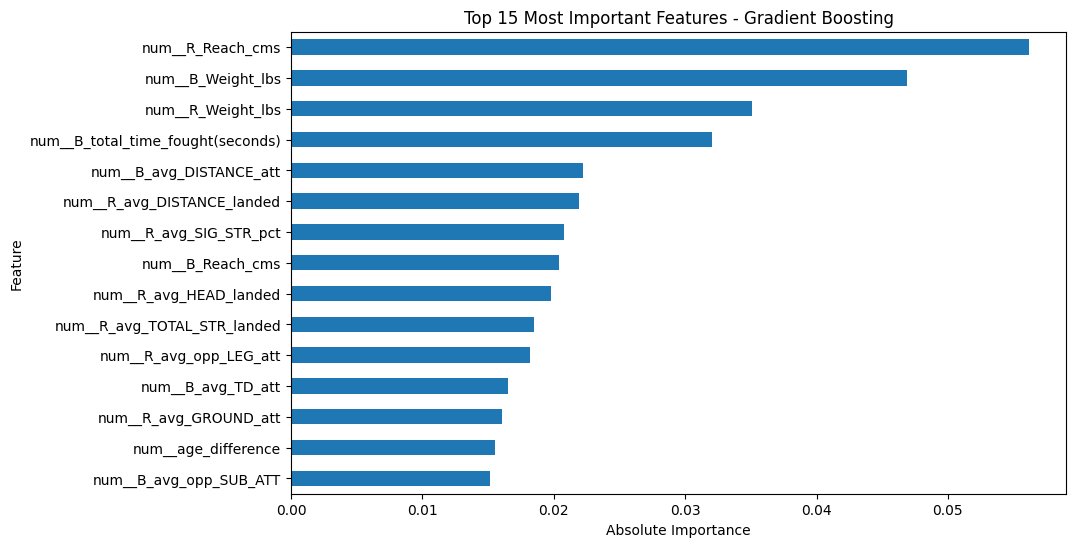

In [15]:
# Extract feature names after preprocessing
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
final_model = best_pipeline.named_steps["model"]

if hasattr(final_model, "coef_"):
    importance_values = final_model.coef_[0]
elif hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
else:
    importance_values = None

if importance_values is not None:
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance_df["Abs_Importance"] = feature_importance_df["Importance"].abs()

    top_features = feature_importance_df.sort_values(
        by="Abs_Importance",
        ascending=False
    ).head(15)

    print(top_features[["Feature", "Importance"]])

    top_features.sort_values("Abs_Importance").plot(
        x="Feature",
        y="Abs_Importance",
        kind="barh",
        figsize=(10, 6),
        legend=False
    )

    plt.title(f"Top 15 Most Important Features - {best_model_name}")
    plt.xlabel("Absolute Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("This model does not provide feature importance.")

## 8. LLM Integration Concept

In addition to the classification model, this project could be extended into an LLM-powered UFC fight preview assistant. The machine learning model would generate a finish-vs-decision prediction and probability score, while the LLM would translate the model output into a plain-language fight preview for fans, analysts, or sports media teams.

The LLM would not replace the classification model. Instead, it would act as an explanation layer that summarizes the prediction, highlights key fighter statistics, and reminds users about model limitations.

In [16]:
# Create model prediction probabilities for LLM-style explanations

# Get prediction probabilities from the best model
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_best = best_pipeline.predict(X_test)

# Build a small results dataframe
llm_results = X_test.copy()
llm_results["actual_result"] = label_encoder.inverse_transform(y_test)
llm_results["predicted_result"] = label_encoder.inverse_transform(y_pred_best)
llm_results["finish_probability"] = y_proba_best

llm_results.head()

,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,...,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age,age_difference,actual_result,predicted_result,finish_probability
2929,False,Lightweight,0.000000,0.250000,0.412500,0.405000,0.332500,0.125000,0.500000,1.500000,...,Orthodox,167.64,170.18,170.0,22.0,33.0,11.0,Decision,Decision,0.385920
3961,False,Heavyweight,0.250000,0.000000,0.425000,0.505000,0.642500,0.125000,0.000000,0.000000,...,Orthodox,210.82,213.36,265.0,30.0,24.0,-6.0,Finish,Finish,0.758848
1844,False,Middleweight,0.000000,0.031250,0.390937,0.430625,0.281562,0.156406,0.015625,0.000000,...,Southpaw,185.42,195.58,185.0,39.0,33.0,-6.0,Finish,Finish,0.577410
180,False,WomenStrawweight,0.000000,0.000000,0.456250,0.426250,0.665000,0.103125,0.000000,0.750000,...,Orthodox,162.56,160.02,115.0,31.0,31.0,0.0,Decision,Decision,0.241574
2247,False,Welterweight,0.261566,0.533203,0.318046,0.422201,0.090893,0.133765,0.125092,0.062866,...,Orthodox,182.88,190.50,170.0,31.0,35.0,4.0,Finish,Finish,0.560415


In [17]:
def create_llm_prompt(row):
    prompt = f"""
You are a UFC fight analyst. Write a short, plain-language fight preview based on the model output and fighter statistics.

Model Prediction:
- Predicted outcome: {row['predicted_result']}
- Finish probability: {row['finish_probability']:.2f}

Available fighter statistics:
- Red fighter age: {row.get('R_age', 'Unknown')}
- Blue fighter age: {row.get('B_age', 'Unknown')}
- Red fighter wins: {row.get('R_wins', 'Unknown')}
- Blue fighter wins: {row.get('B_wins', 'Unknown')}
- Red fighter losses: {row.get('R_losses', 'Unknown')}
- Blue fighter losses: {row.get('B_losses', 'Unknown')}
- Red average submission attempts: {row.get('R_avg_SUB_ATT', 'Unknown')}
- Blue average submission attempts: {row.get('B_avg_SUB_ATT', 'Unknown')}
- Red average takedowns landed: {row.get('R_avg_TD_landed', 'Unknown')}
- Blue average takedowns landed: {row.get('B_avg_TD_landed', 'Unknown')}

Important limitation:
This prediction is based only on historical pre-fight data. It does not include injuries, training camp changes, weight-cut issues, short-notice replacements, or strategy changes.

Write the preview in one short paragraph.
"""
    return prompt

sample_prompt = create_llm_prompt(llm_results.iloc[0])
print(sample_prompt)


You are a UFC fight analyst. Write a short, plain-language fight preview based on the model output and fighter statistics.

Model Prediction:
- Predicted outcome: Decision
- Finish probability: 0.39

Available fighter statistics:
- Red fighter age: 33.0
- Blue fighter age: 22.0
- Red fighter wins: 2
- Blue fighter wins: 2
- Red fighter losses: 1
- Blue fighter losses: 1
- Red average submission attempts: 0.0
- Blue average submission attempts: 0.5
- Red average takedowns landed: 4.0
- Blue average takedowns landed: 3.25

Important limitation:
This prediction is based only on historical pre-fight data. It does not include injuries, training camp changes, weight-cut issues, short-notice replacements, or strategy changes.

Write the preview in one short paragraph.



## 9. Limitations

Fight outcomes are difficult to predict because the data does not fully capture injuries, training camp changes, short-notice fights, weight-cut issues, strategy changes, or fighter health. The model should support human analysis, not replace expert judgment.

## 10. Deployment Plan

A realistic deployment approach would be a batch scoring tool before each UFC event. A user could upload upcoming fight-card data and receive finish-probability scores for each matchup. These predictions could support media previews, analyst notes, rankings, and fan engagement content. The model should be retrained periodically as new UFC fight data becomes available.

## 11. Final Recommendation
The model is useful as an analytics support tool for UFC fight previews and media content. It should not be used as betting advice or as a standalone decision-making system.